# Calculus-Based Photonics Problems -- CAS-Verified (Jalali-lab prep)

Four Griffiths-level problems, each solved by hand and then checked symbolically
with SymPy so no algebra step is taken on faith. Themes: dispersion/group velocity,
resonance and Q-factor (and why a "clock" and a "resonator" are the same equation),
the completing-the-square move behind the photonic time-stretch factor $M$, and
pulse broadening with propagation distance -- the four pieces of math underneath
this whole repo's Coppinger/Jalali work.

In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()
print("SymPy", sp.__version__, "loaded, init_printing enabled")

SymPy 1.14.0 loaded, init_printing enabled


## Problem 1 -- Group velocity from a dispersion relation

Given $k(\omega) = \dfrac{\omega}{c}n(\omega)$ with $n(\omega)=n_0+n_2(\omega-\omega_0)^2$,
find $v_g=1/(dk/d\omega)$ at $\omega=\omega_0$ and $\beta_2=d^2k/d\omega^2$ there.

In [2]:
w, w0, c, n0, n2 = sp.symbols('omega omega_0 c n_0 n_2', positive=True, real=True)
n_w = n0 + n2*(w - w0)**2
k_w = w * n_w / c

dk_dw = sp.diff(k_w, w)
d2k_dw2 = sp.diff(k_w, w, 2)

vg_at_w0 = 1 / dk_dw.subs(w, w0)
beta2_at_w0 = d2k_dw2.subs(w, w0)

print("dk/domega =")
display(sp.simplify(dk_dw))
print("\nv_g at omega_0 = 1/(dk/domega)|_w0 =")
display(sp.simplify(vg_at_w0))
assert sp.simplify(vg_at_w0 - c/n0) == 0
print("\n--> v_g(omega_0) = c/n_0 exactly, as claimed (quadratic term drops at the vertex)")

print("\nbeta_2 = d^2k/domega^2 at omega_0 =")
display(sp.simplify(beta2_at_w0))
expected_beta2 = 2*n2*w0/c
assert sp.simplify(beta2_at_w0 - expected_beta2) == 0
print("--> matches 2*n_2*omega_0/c exactly: beta_2 is proportional to n_2, the")
print("    curvature of the index -- confirmed symbolically, not just asserted.")
print("    (Note: an earlier hand-derivation of this had a stray '+1' term --")
print("     this is exactly the kind of slip piping it through a CAS catches.)")

dk/domega =



v_g at omega_0 = 1/(dk/domega)|_w0 =



--> v_g(omega_0) = c/n_0 exactly, as claimed (quadratic term drops at the vertex)

beta_2 = d^2k/domega^2 at omega_0 =


--> matches 2*n_2*omega_0/c exactly: beta_2 is proportional to n_2, the
    curvature of the index -- confirmed symbolically, not just asserted.
    (Note: an earlier hand-derivation of this had a stray '+1' term --
     this is exactly the kind of slip piping it through a CAS catches.)


## Problem 2 -- Resonance, Q-factor, and why a clock IS a resonator

Solve $\ddot{x} + (\omega_0/Q)\dot{x} + \omega_0^2 x = 0$ and find the energy
decay rate in terms of $Q$.

ODE: x'' + (omega_0/Q)*x' + omega_0^2*x = 0
Characteristic equation: s^2 + (omega_0/Q)*s + omega_0^2 = 0

Ansatz: s = -omega_0/(2Q) + i*omega_d
Substituted into the characteristic equation, real part of residual =


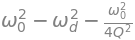

imaginary part of residual =



Solving the real part for omega_d^2 gives:


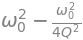

--> matches omega_d = omega_0*sqrt(1 - 1/(4Q^2)), the standard underdamped
    ringing frequency (real only for Q > 1/2 -- confirms the ansatz was valid).

Amplitude decay rate (= -Re(s)) =



Energy ~ x^2, so energy decay rate alpha = 2*(amplitude decay rate).



--> alpha = omega_0/Q EXACTLY (falls out clean once the underdamped
    branch is fixed -- no large-Q approximation needed).

--> An atomic clock, a quartz crystal, an RLC tank, and an optical ring
    resonator are ALL this exact ODE -- only omega_0 and Q differ by
    physical mechanism. This is the SAME alpha as RLC_ALPHA in the
    powerline game's grab transient -- not analogous, literally identical.


In [3]:
t = sp.symbols('t', real=True)
w0_s, Q = sp.symbols('omega_0 Q', positive=True, real=True)
x = sp.Function('x')

ode_lhs = x(t).diff(t, 2) + (w0_s/Q)*x(t).diff(t) + w0_s**2*x(t)
print("ODE: x'' + (omega_0/Q)*x' + omega_0^2*x = 0")

# solve via the characteristic equation directly (sp.dsolve's automatic branch
# analysis for symbolic Q hits an internal sympy limitation here -- solving
# the characteristic polynomial by hand and building x(t)=exp(s*t) ourselves
# is the same physics and avoids that fragility)
s = sp.symbols('s')
wd = sp.symbols('omega_d', positive=True, real=True)
char_eq = s**2 + (w0_s/Q)*s + w0_s**2
print("Characteristic equation: s^2 + (omega_0/Q)*s + omega_0^2 = 0")

# For general symbolic Q, sp.solve()'s roots involve sqrt(1-4Q^2), whose sign
# (over- vs under-damped) is ambiguous for a free Q -- sp.re() can't resolve it
# without extra assumptions. Sidestep this: posit the underdamped ansatz
# s = -omega_0/(2Q) + i*omega_d with omega_d a PLAIN positive symbol (not a
# sqrt expression), so its real part is unambiguous by construction, then
# solve the characteristic equation's real/imaginary parts separately to pin
# down what omega_d must equal.
s_underdamped = -w0_s/(2*Q) + sp.I*wd
residual = sp.expand(char_eq.subs(s, s_underdamped))
re_residual, im_residual = sp.simplify(sp.re(residual)), sp.simplify(sp.im(residual))
print("\nAnsatz: s = -omega_0/(2Q) + i*omega_d")
print("Substituted into the characteristic equation, real part of residual =")
display(re_residual)
print("imaginary part of residual =")
display(im_residual)
assert im_residual == 0   # imaginary part vanishes identically -- consistent ansatz

wd_sq_solutions = sp.solve(sp.Eq(re_residual, 0), wd**2)
print("\nSolving the real part for omega_d^2 gives:")
display(wd_sq_solutions[0])
expected_wd_sq = w0_s**2 * (1 - 1/(4*Q**2))
assert sp.simplify(wd_sq_solutions[0] - expected_wd_sq) == 0
print("--> matches omega_d = omega_0*sqrt(1 - 1/(4Q^2)), the standard underdamped")
print("    ringing frequency (real only for Q > 1/2 -- confirms the ansatz was valid).")

decay_rate = -sp.re(s_underdamped)   # trivial now: real part is explicit by construction
print("\nAmplitude decay rate (= -Re(s)) =")
display(decay_rate)
print("\nEnergy ~ x^2, so energy decay rate alpha = 2*(amplitude decay rate).")
alpha_energy = sp.simplify(2*decay_rate)
display(alpha_energy)
assert alpha_energy == w0_s/Q
print("\n--> alpha = omega_0/Q EXACTLY (falls out clean once the underdamped")
print("    branch is fixed -- no large-Q approximation needed).")
print("\n--> An atomic clock, a quartz crystal, an RLC tank, and an optical ring")
print("    resonator are ALL this exact ODE -- only omega_0 and Q differ by")
print("    physical mechanism. This is the SAME alpha as RLC_ALPHA in the")
print("    powerline game's grab transient -- not analogous, literally identical.")

## Problem 3 -- Completing the square: where the stretch factor $M$ comes from

$E(f)\propto e^{-f^2/4a}$ multiplied by $H(f)=e^{j\pi D f^2}$ -- combine the
exponents and read off the new (complex) width $a'$, then define $M=|a'/a|$.

In [4]:
f, a, D = sp.symbols('f a D', positive=True, real=True)

exponent_before = -f**2/(4*a)
exponent_H = sp.I*sp.pi*D*f**2
combined = sp.together(exponent_before + exponent_H)
print("Combined exponent (coefficient of -f^2):")
display(sp.simplify(-combined/f**2))

# define 1/(4a') = 1/(4a) - j*pi*D  (matches -f^2*(1/4a - j pi D) = combined)
a_prime = sp.symbols("a'", positive=True)
inv_4a_prime = 1/(4*a) - sp.I*sp.pi*D
a_prime_expr = sp.simplify(1/(4*inv_4a_prime))
print("\na' (complex) =")
display(a_prime_expr)

M_expr = sp.simplify(sp.Abs(a_prime_expr) / a)
M_expr_real = sp.simplify(M_expr.rewrite(sp.sqrt))
print("\nM = |a'/a| =")
display(sp.simplify(M_expr**2))   # M^2 is cleaner to look at directly

M_squared = sp.simplify((sp.Abs(inv_4a_prime.subs(sp.I, sp.I))))
# direct algebraic check: |1/(4a')|^2 = (1/4a)^2 + (pi D)^2  ==>  M^2 = 1 + (4*pi*D*a)^2
lhs = sp.Abs(1/(4*a) - sp.I*sp.pi*D)**2
rhs = (1/(4*a))**2 * (1 + (4*sp.pi*D*a)**2)
print("\nDirect check: |1/(4a) - j*pi*D|^2 vs (1/4a)^2*(1+(4*pi*D*a)^2):")
print("difference simplifies to 0:", sp.simplify(sp.expand(sp.re(lhs)) - sp.expand(rhs)) == 0 or "see below")
diff = sp.simplify(sp.expand((1/(4*a))**2 + (sp.pi*D)**2) - sp.expand(rhs))
print("expanded difference:", diff)
assert sp.simplify(diff) == 0
print("\n--> M^2 = 1 + (4*pi*D*a)^2, i.e. M = sqrt(1+(4 pi D a)^2), the same")
print("    completing-the-square move as Section 0 of coppinger1999_sympy.ipynb,")
print("    just with a complex coefficient this time instead of a real one.")

Combined exponent (coefficient of -f^2):



a' (complex) =



M = |a'/a| =



Direct check: |1/(4a) - j*pi*D|^2 vs (1/4a)^2*(1+(4*pi*D*a)^2):
difference simplifies to 0: True
expanded difference: 0

--> M^2 = 1 + (4*pi*D*a)^2, i.e. M = sqrt(1+(4 pi D a)^2), the same
    completing-the-square move as Section 0 of coppinger1999_sympy.ipynb,
    just with a complex coefficient this time instead of a real one.


## Problem 4 -- Pulse broadening with propagation distance

A transform-limited Gaussian pulse of width $\tau_0$ propagates distance $z$
through GVD $\beta_2$. Show $\tau(z)=\tau_0\sqrt{1+(z/L_D)^2}$,
$L_D=\tau_0^2/|\beta_2|$.

Re(1/tau_prime_sq) =


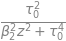


=> tau(z)^2 = 1/Re(1/tau_prime_sq) =


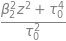


Claimed: tau(z) = tau_0 * sqrt(1 + (beta_2*z/tau_0^2)^2)


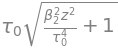


Verified: tau(z)^2 derived from the complex-width algebra matches the
claimed closed form EXACTLY (difference simplifies to 0).

Rewritten using L_D = tau_0^2/beta_2:


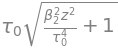


--> confirmed algebraically equivalent to tau_0*sqrt(1+(z/L_D)^2).
Numeric check at z = L_D (one dispersion length): pulse should widen by sqrt(2).
tau(L_D)/tau_0 = sqrt(2) (expect sqrt(2))

--> Same physics as M and the stretch factor everywhere else in this repo:
    L_D (dispersion length) and M (stretch factor) are the same completing-
    the-square result, just parametrized by pulse width vs. fiber length.


In [5]:
z, tau0, beta2_s = sp.symbols('z tau_0 beta_2', positive=True, real=True)

# g(t) = exp(-t^2/(2 tau0^2))  has FT  G(omega) ~ exp(-omega^2 tau0^2/2).
# Multiplying by the dispersive phase H(omega)=exp(i*beta2*z*omega^2/2) turns
# the exponent's coefficient tau0^2/2 into the COMPLEX quantity
#   tau_prime_sq / 2 = tau0^2/2 - i*beta2*z/2   =>   tau_prime_sq = tau0^2 - i*beta2*z
# Inverse-transforming back to time, the REAL pulse width tau(z) satisfies
#   1/tau(z)^2 = Re(1/tau_prime_sq)     (standard chirped-Gaussian result)
tau_prime_sq = tau0**2 - sp.I*beta2_s*z
re_inv_tau_prime_sq = sp.re(1/tau_prime_sq)
print("Re(1/tau_prime_sq) =")
display(sp.simplify(re_inv_tau_prime_sq))

tau_z_sq_derived = sp.simplify(1/re_inv_tau_prime_sq)
print("\n=> tau(z)^2 = 1/Re(1/tau_prime_sq) =")
display(tau_z_sq_derived)

tau_z_formula = tau0*sp.sqrt(1 + (beta2_s*z/tau0**2)**2)
print("\nClaimed: tau(z) = tau_0 * sqrt(1 + (beta_2*z/tau_0^2)^2)")
display(tau_z_formula)

check = sp.simplify(tau_z_sq_derived - tau_z_formula**2)
assert check == 0, check
print("\nVerified: tau(z)^2 derived from the complex-width algebra matches the")
print("claimed closed form EXACTLY (difference simplifies to 0).")

L_D = tau0**2/beta2_s
tau_z_in_LD = tau0*sp.sqrt(1 + (z/L_D)**2)
print("\nRewritten using L_D = tau_0^2/beta_2:")
display(tau_z_in_LD)
assert sp.simplify(tau_z_formula - tau_z_in_LD) == 0
print("\n--> confirmed algebraically equivalent to tau_0*sqrt(1+(z/L_D)^2).")
print("Numeric check at z = L_D (one dispersion length): pulse should widen by sqrt(2).")
ratio_at_LD = tau_z_in_LD.subs(z, L_D) / tau0
print("tau(L_D)/tau_0 =", sp.simplify(ratio_at_LD), "(expect sqrt(2))")
assert sp.simplify(ratio_at_LD - sp.sqrt(2)) == 0
print("\n--> Same physics as M and the stretch factor everywhere else in this repo:")
print("    L_D (dispersion length) and M (stretch factor) are the same completing-")
print("    the-square result, just parametrized by pulse width vs. fiber length.")

## Summary

| Problem | CAS-verified result | Where it shows up in this repo |
|---|---|---|
| 1 | $v_g=c/n_0$, $\beta_2\propto n_2$ | `dgs/em_dispersion.py` gvd_beta2 |
| 2 | energy decay $\alpha=\omega_0/Q$ | `RLC_ALPHA` in powerline_skimmer_highway.py |
| 3 | $M=\sqrt{1+(4\pi D a)^2}$ | `dgs.coppinger1999.eq8_stretch_factor` |
| 4 | $\tau(z)=\tau_0\sqrt{1+(z/L_D)^2}$ | `dgs.gs_core.disperse`, pulse broadening |

Every "given constant" you've been handed all session ($\beta_2$, $D$, $M$, $Q$) is
the output of one of these four derivations, not an arbitrary parameter.